# Parte 2: Regresión Logística - Predicción de aprobación de estudiantes

Este notebook desarrolla un ejercicio práctico guiado de **Machine Learning supervisado** usando **Regresión Logística**.

El objetivo es predecir si un estudiante aprobará un examen a partir de una variable muy sencilla: la cantidad de **horas de estudio**.

La salida del modelo será binaria:

- `0`: no aprobó.
- `1`: aprobó.


## 1. Explicación breve del problema

Queremos resolver un problema de **clasificación binaria**. Esto significa que el modelo debe elegir entre dos clases posibles: aprobar o no aprobar.

Aunque el ejemplo es simple, representa una idea muy importante: la regresión logística no predice directamente una nota, sino una **probabilidad de pertenecer a una clase**. En este caso, calcula la probabilidad de que un estudiante apruebe según las horas estudiadas.

Después convertimos esa probabilidad en una clase usando un umbral. Normalmente se usa `0.5`:

- Si la probabilidad es mayor o igual a `0.5`, predecimos `aprobado = 1`.
- Si la probabilidad es menor que `0.5`, predecimos `aprobado = 0`.


## 2. Importacón de librerías

Usaremos librerías habituales en ciencia de datos:

- `numpy` para cálculos numéricos.
- `pandas` para trabajar con tablas.
- `matplotlib` para visualizar los datos.
- `scikit-learn` para dividir los datos, entrenar el modelo y evaluar resultados.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

# Configuración visual sencilla para que los gráficos sean más claros.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Librerías importadas correctamente.')


Librerías importadas correctamente.


## 3. Creación del dataset

En el repositorio no había un dataset previo, así que crearemos uno sintético dentro del notebook.

Para que el ejercicio sea reproducible usamos una semilla aleatoria (`seed=42`). Esto permite que, si otra persona ejecuta el notebook, obtenga los mismos datos y resultados.

El dataset tendrá dos columnas:

- `horas_estudio`: cantidad de horas estudiadas.
- `aprobado`: resultado del examen, donde `0` significa no aprobado y `1` significa aprobado.

La idea general será que, a más horas de estudio, mayor probabilidad de aprobar. Pero añadiremos algo de variabilidad para que el ejemplo se parezca un poco más a una situación real.


In [6]:
# Generamos datos reproducibles.
rng = np.random.default_rng(seed=42)

# Creamos 40 valores de horas de estudio entre 0.5 y 10 horas, con un poco de ruido.
horas_estudio = np.round(np.linspace(0.5, 10, 40) + rng.normal(0, 0.35, 40), 1)
horas_estudio = np.clip(horas_estudio, 0.5, 10)

# Convertimos las horas en una probabilidad usando una función sigmoide.
# La probabilidad aumenta alrededor de las 5 horas de estudio.
probabilidad_real = 1 / (1 + np.exp(-1.25 * (horas_estudio - 5)))

# Generamos la variable objetivo con cierta variabilidad.
aprobado = rng.binomial(n=1, p=probabilidad_real)

# Construimos el DataFrame final.
datos = pd.DataFrame({
    'horas_estudio': horas_estudio,
    'aprobado': aprobado,
})

print('Primeras filas del dataset:')
print(datos.head(10).to_string(index=False))


Primeras filas del dataset:
 horas_estudio  aprobado
           0.6         0
           0.5         0
           1.2         0
           1.6         0
           0.8         0
           1.3         0
           2.0         0
           2.1         0
           2.4         0
           2.4         0


## 4. Exploración inicial de los datos

Antes de entrenar un modelo, conviene revisar qué contiene el dataset: tamaño, tipos de variables, valores resumen y distribución de la clase objetivo.


In [7]:
print('Dimensiones del dataset:', datos.shape)
print('\nTipos de datos:')
print(datos.dtypes)

print('\nResumen estadístico:')
print(datos.describe().to_string())

print('\nCantidad de estudiantes por clase:')
print(datos['aprobado'].value_counts().rename(index={0: 'No aprobado', 1: 'Aprobado'}).to_string())


Dimensiones del dataset: (40, 2)

Tipos de datos:
horas_estudio    float64
aprobado           int64
dtype: object

Resumen estadístico:
       horas_estudio   aprobado
count      40.000000  40.000000
mean        5.262500   0.525000
std         2.880321   0.505736
min         0.500000   0.000000
25%         3.000000   0.000000
50%         5.250000   1.000000
75%         7.750000   1.000000
max        10.000000   1.000000

Cantidad de estudiantes por clase:
aprobado
Aprobado       21
No aprobado    19


## 5. Visualización simple de la relación entre horas y aprobación

El siguiente gráfico muestra cada estudiante como un punto. En el eje X vemos las horas de estudio y en el eje Y el resultado real del examen.

Como `aprobado` solo puede valer `0` o `1`, los puntos aparecen en dos niveles:

- Abajo: estudiantes que no aprobaron.
- Arriba: estudiantes que aprobaron.


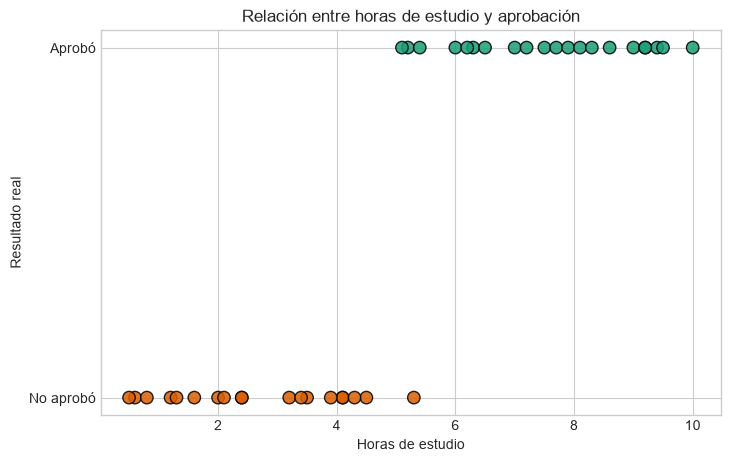

In [8]:
colores = datos['aprobado'].map({0: '#d95f02', 1: '#1b9e77'})

plt.scatter(datos['horas_estudio'], datos['aprobado'], c=colores, s=80, edgecolor='black', alpha=0.85)
plt.yticks([0, 1], ['No aprobó', 'Aprobó'])
plt.xlabel('Horas de estudio')
plt.ylabel('Resultado real')
plt.title('Relación entre horas de estudio y aprobación')
plt.show()


## 6. Separación de variables: X e Y

En Machine Learning se suele separar el dataset en:

- `X`: variables de entrada o características. Aquí será `horas_estudio`.
- `y`: variable objetivo o etiqueta. Aquí será `aprobado`.

Scikit-learn espera que `X` tenga formato de tabla, aunque solo tenga una columna. Por eso usamos doble corchete: `datos[['horas_estudio']]`.


In [9]:
X = datos[['horas_estudio']]
y = datos['aprobado']

print('Primeras filas de X:')
print(X.head().to_string(index=False))

print('\nPrimeros valores de y:')
print(y.head().to_string(index=False))

print('\nForma de X:', X.shape)
print('Forma de y:', y.shape)


Primeras filas de X:
 horas_estudio
           0.6
           0.5
           1.2
           1.6
           0.8

Primeros valores de y:
0
0
0
0
0

Forma de X: (40, 1)
Forma de y: (40,)


## 7. División en entrenamiento y prueba

Dividimos los datos en dos partes:

- **Entrenamiento**: datos que el modelo usa para aprender.
- **Prueba**: datos que el modelo no vio durante el entrenamiento y que usamos para evaluar si generaliza bien.

Usamos `stratify=y` para mantener una proporción similar de aprobados y no aprobados en ambos conjuntos.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print('Tamaño del conjunto de entrenamiento:', X_train.shape[0], 'filas')
print('Tamaño del conjunto de prueba:', X_test.shape[0], 'filas')

print('\nDistribución en entrenamiento:')
print(y_train.value_counts().sort_index().rename(index={0: 'No aprobado', 1: 'Aprobado'}).to_string())

print('\nDistribución en prueba:')
print(y_test.value_counts().sort_index().rename(index={0: 'No aprobado', 1: 'Aprobado'}).to_string())


Tamaño del conjunto de entrenamiento: 30 filas
Tamaño del conjunto de prueba: 10 filas

Distribución en entrenamiento:
aprobado
No aprobado    14
Aprobado       16

Distribución en prueba:
aprobado
No aprobado    5
Aprobado       5


## 8. Entrenamiento del modelo de Regresión Logística

Ahora creamos y entrenamos el modelo con `LogisticRegression`.

La regresión logística aprende una curva sigmoide. Esa curva transforma las horas de estudio en una probabilidad entre 0 y 1.


In [11]:
modelo = LogisticRegression(random_state=42)
modelo.fit(X_train, y_train)

print('Modelo entrenado correctamente.')
print(f'Intercepto (beta0): {modelo.intercept_[0]:.4f}')
print(f'Coeficiente para horas_estudio (beta1): {modelo.coef_[0][0]:.4f}')

if modelo.coef_[0][0] > 0:
    print('Interpretación: al aumentar las horas de estudio, aumenta la probabilidad estimada de aprobar.')
else:
    print('Interpretación: al aumentar las horas de estudio, disminuye la probabilidad estimada de aprobar.')


Modelo entrenado correctamente.
Intercepto (beta0): -8.9134
Coeficiente para horas_estudio (beta1): 1.7010
Interpretación: al aumentar las horas de estudio, aumenta la probabilidad estimada de aprobar.


## 9. Predicciones sobre el conjunto de prueba

Con el modelo ya entrenado, hacemos predicciones sobre los datos de prueba.

Obtendremos dos cosas:

- `y_pred`: clase predicha, `0` o `1`.
- `y_proba`: probabilidad estimada de aprobar.


In [12]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

resultados_prueba = X_test.copy()
resultados_prueba['aprobado_real'] = y_test.values
resultados_prueba['probabilidad_aprobar'] = y_proba
resultados_prueba['prediccion'] = y_pred
resultados_prueba = resultados_prueba.sort_values('horas_estudio')

print(resultados_prueba.to_string(index=False, formatters={'probabilidad_aprobar': '{:.3f}'.format}))


 horas_estudio  aprobado_real probabilidad_aprobar  prediccion
           2.0              0                0.004           0
           2.1              0                0.005           0
           3.2              0                0.030           0
           3.4              0                0.042           0
           4.1              0                0.126           0
           5.1              1                0.441           0
           5.2              1                0.483           0
           8.6              1                0.997           1
           9.2              1                0.999           1
           9.4              1                0.999           1


## 10. Evaluación del modelo

Para evaluar un modelo de clasificación no alcanza con mirar una sola métrica. Revisaremos:

- **Accuracy**: porcentaje total de aciertos.
- **Matriz de confusi?n**: tipos de aciertos y errores.
- **Precision**: de todo lo predicho como aprobado, cuánto realmente aprobó.
- **Recall**: de todos los aprobados reales, cuántos encontró el modelo.
- **F1-score**: equilibrio entre precision y recall.
- **Classification report**: resumen de métricas por clase.
- **ROC-AUC**: capacidad del modelo para separar aprobados de no aprobados usando probabilidades.


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
matriz = confusion_matrix(y_test, y_pred)

print(f'Accuracy:  {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall:    {recall:.3f}')
print(f'F1-score:  {f1:.3f}')
print(f'ROC-AUC:   {roc_auc:.3f}')

print('\nMatriz de confusión:')
print(matriz)

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['No aprobado', 'Aprobado']))


Accuracy:  0.800
Precision: 1.000
Recall:    0.600
F1-score:  0.750
ROC-AUC:   1.000

Matriz de confusión:
[[5 0]
 [2 3]]

Classification report:
              precision    recall  f1-score   support

 No aprobado       0.71      1.00      0.83         5
    Aprobado       1.00      0.60      0.75         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10



## 11. Visualización de la matriz de confusión

La matriz de confusión compara lo que ocurrió realmente con lo que predijo el modelo.

En este problema:

- Verdaderos negativos: estudiantes que no aprobaron y el modelo predijo que no aprobarían.
- Verdaderos positivos: estudiantes que aprobaron y el modelo predijo que aprobar?an.
- Falsos positivos: el modelo predijo aprobado, pero no aprobó.
- Falsos negativos: el modelo predijo no aprobado, pero sí aprobó.


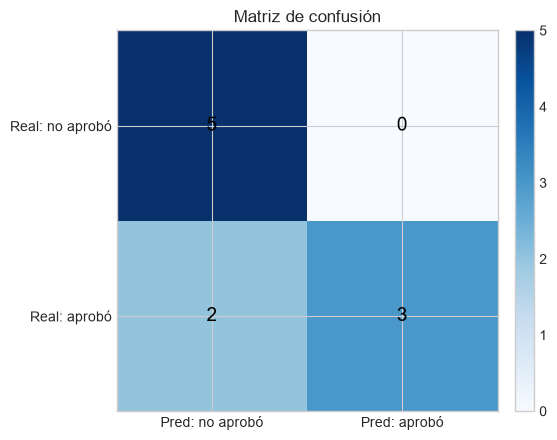

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(matriz, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: no aprobó', 'Pred: aprobó'])
ax.set_yticklabels(['Real: no aprobó', 'Real: aprobó'])
ax.set_title('Matriz de confusión')

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        ax.text(j, i, matriz[i, j], ha='center', va='center', color='black', fontsize=14)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 12. Curva ROC y ROC-AUC

La curva ROC evalúa el comportamiento del modelo si cambiamos el umbral de decisión.

El valor **ROC-AUC** resume esa curva en un número entre 0 y 1:

- Cerca de `0.5`: el modelo separa las clases casi como azar.
- Cerca de `1.0`: el modelo separa muy bien las clases.


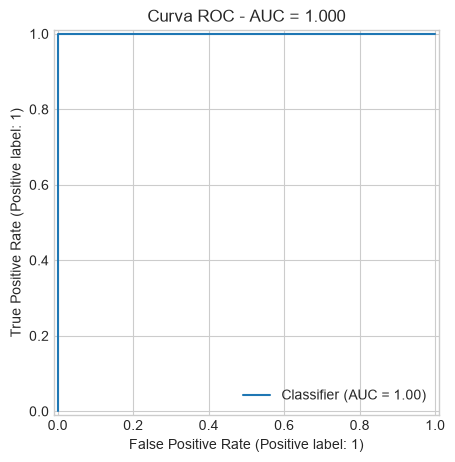

In [15]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f'Curva ROC - AUC = {roc_auc:.3f}')
plt.show()


## 13. Visualización de la curva sigmoide y frontera de decisión

La regresión logística produce una curva en forma de S llamada **sigmoide**.

Esa curva representa la probabilidad de aprobar según las horas estudiadas. La frontera de decisión aparece cuando la probabilidad llega a `0.5`.


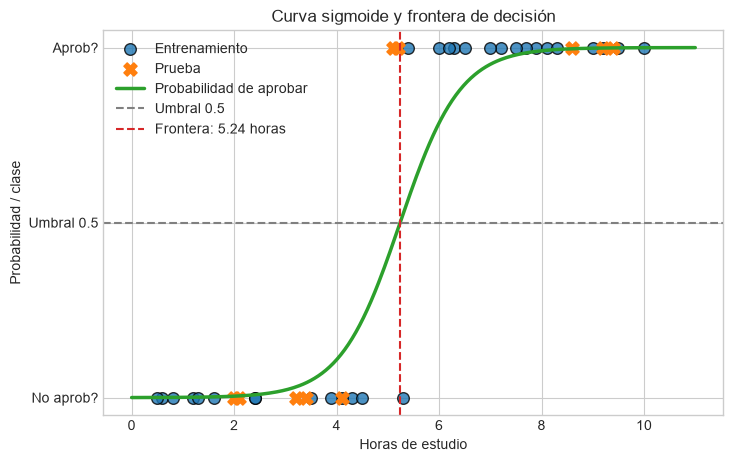

Frontera de decisión aproximada: 5.24 horas de estudio.


In [16]:
horas_grid = pd.DataFrame({'horas_estudio': np.linspace(0, 11, 300)})
probabilidades_grid = modelo.predict_proba(horas_grid)[:, 1]

# Calculamos la hora aproximada en la que la probabilidad llega a 0.5.
frontera_decision = -modelo.intercept_[0] / modelo.coef_[0][0]

plt.scatter(X_train['horas_estudio'], y_train, color='#1f77b4', label='Entrenamiento', s=70, alpha=0.8, edgecolor='black')
plt.scatter(X_test['horas_estudio'], y_test, color='#ff7f0e', label='Prueba', s=90, marker='X')
plt.plot(horas_grid['horas_estudio'], probabilidades_grid, color='#2ca02c', linewidth=2.5, label='Probabilidad de aprobar')
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral 0.5')
plt.axvline(frontera_decision, color='#d62728', linestyle='--', label=f'Frontera: {frontera_decision:.2f} horas')
plt.yticks([0, 0.5, 1], ['No aprob?', 'Umbral 0.5', 'Aprob?'])
plt.xlabel('Horas de estudio')
plt.ylabel('Probabilidad / clase')
plt.title('Curva sigmoide y frontera de decisión')
plt.legend()
plt.show()

print(f'Frontera de decisión aproximada: {frontera_decision:.2f} horas de estudio.')


## 14. Ejemplos de predicción con nuevos estudiantes

Probamos el modelo con dos casos nuevos:

- Un estudiante que estudió pocas horas.
- Un estudiante que estudió muchas horas.

Esto nos ayuda a ver cómo se usaría el modelo en una situación nueva.


In [17]:
nuevos_estudiantes = pd.DataFrame({
    'horas_estudio': [2, 9]
})

nuevas_probabilidades = modelo.predict_proba(nuevos_estudiantes)[:, 1]
nuevas_predicciones = modelo.predict(nuevos_estudiantes)

predicciones_nuevas = nuevos_estudiantes.copy()
predicciones_nuevas['probabilidad_aprobar'] = nuevas_probabilidades
predicciones_nuevas['prediccion'] = nuevas_predicciones
predicciones_nuevas['interpretacion'] = predicciones_nuevas['prediccion'].map({0: 'No aprobar?a', 1: 'Aprobar?a'})

print(predicciones_nuevas.to_string(index=False, formatters={'probabilidad_aprobar': '{:.3f}'.format}))


 horas_estudio probabilidad_aprobar  prediccion interpretacion
             2                0.004           0   No aprobar?a
             9                0.998           1      Aprobar?a


## 15. Conclusión final

En este ejercicio aprendimos a construir un flujo básico de clasificación supervisada con **Regresión Logística**:

1. Creamos un dataset simple y reproducible.
2. Exploramos la relación entre horas de estudio y aprobación.
3. Separamos las variables en `X` e `y`.
4. Dividimos los datos en entrenamiento y prueba.
5. Entrenamos un modelo con `LogisticRegression`.
6. Evaluamos el modelo con métricas de clasificación.
7. Visualizamos la matriz de confusión, la curva ROC y la curva sigmoide.
8. Usamos el modelo para predecir nuevos casos.

La idea principal es que la regresión logística no solo devuelve una clase final, sino también una **probabilidad**. Esa probabilidad permite entender mejor la incertidumbre del modelo y tomar decisiones más informadas.

Este ejemplo es pequeño y educativo. En un caso real, probablemente usaríamos más variables, como asistencia, entregas, participación o notas previas. Aun así, el flujo general sería muy parecido.
